In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier

In [2]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv
Saving hour.csv to hour.csv


In [3]:
df = pd.read_csv('/content/hour.csv')

In [4]:
df = df.drop(['instant','dteday','casual','registered'], axis=1, errors='ignore')

In [5]:
df['target'] = pd.cut(df['cnt'], bins=2, labels=[0,1])
df['target'] = df['target'].astype(int)


In [6]:
print("Unique classes:", df['target'].unique())

Unique classes: [0 1]


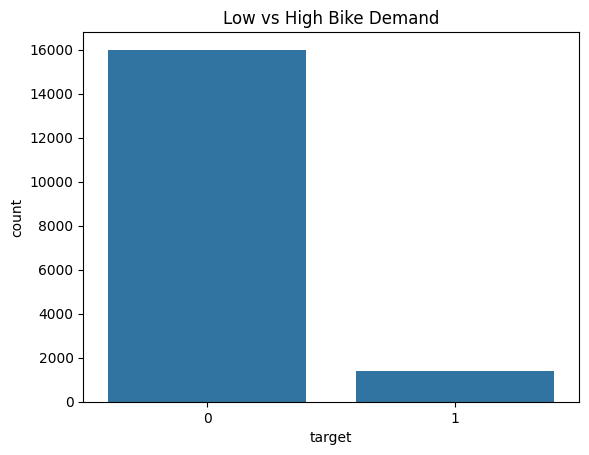

In [7]:
sns.countplot(x='target', data=df)
plt.title("Low vs High Bike Demand")
plt.show()


In [8]:
df = df.drop('cnt', axis=1)

In [9]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop('target', axis=1)
y = df['target']

In [11]:
results = []

In [12]:
model = KNeighborsClassifier()
print("\nRunning Model: KNeighborsClassifier")




Running Model: KNeighborsClassifier


In [13]:

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

model.fit(X_train1, y_train1)
y_pred1 = model.predict(X_test1)

print("\n===== 80:20 SPLIT =====")

acc1 = accuracy_score(y_test1, y_pred1)
prec1 = precision_score(y_test1, y_pred1, average='weighted')
rec1 = recall_score(y_test1, y_pred1, average='weighted')
f11 = f1_score(y_test1, y_pred1, average='weighted')

print(f"Accuracy  : {acc1:.4f}")
print(f"Precision : {prec1:.4f}")
print(f"Recall    : {rec1:.4f}")
print(f"F1 Score  : {f11:.4f}")


===== 80:20 SPLIT =====
Accuracy  : 0.9335
Precision : 0.9236
Recall    : 0.9335
F1 Score  : 0.9263



Confusion Matrix (80:20):
 [[3144   65]
 [ 166  101]]


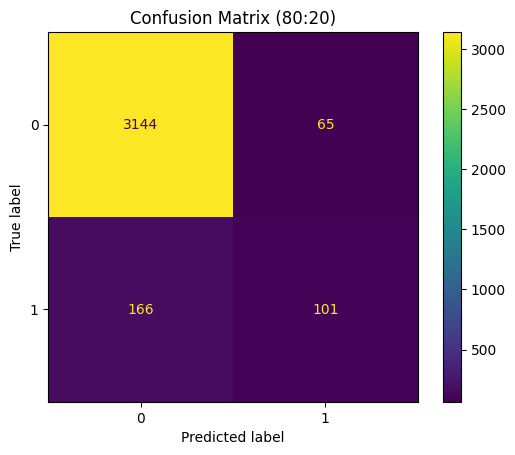

In [14]:
cm1 = confusion_matrix(y_test1, y_pred1)
print("\nConfusion Matrix (80:20):\n", cm1)

ConfusionMatrixDisplay(cm1).plot()
plt.title("Confusion Matrix (80:20)")
plt.show()

In [15]:

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3)

X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

model.fit(X_train2, y_train2)
y_pred2 = model.predict(X_test2)

print("\n===== 70:30 SPLIT =====")

acc2 = accuracy_score(y_test2, y_pred2)
prec2 = precision_score(y_test2, y_pred2, average='weighted')
rec2 = recall_score(y_test2, y_pred2, average='weighted')
f12 = f1_score(y_test2, y_pred2, average='weighted')

print(f"Accuracy  : {acc2:.4f}")
print(f"Precision : {prec2:.4f}")
print(f"Recall    : {rec2:.4f}")
print(f"F1 Score  : {f12:.4f}")


===== 70:30 SPLIT =====
Accuracy  : 0.9333
Precision : 0.9225
Recall    : 0.9333
F1 Score  : 0.9254



Confusion Matrix (70:30):
 [[4726   95]
 [ 253  140]]


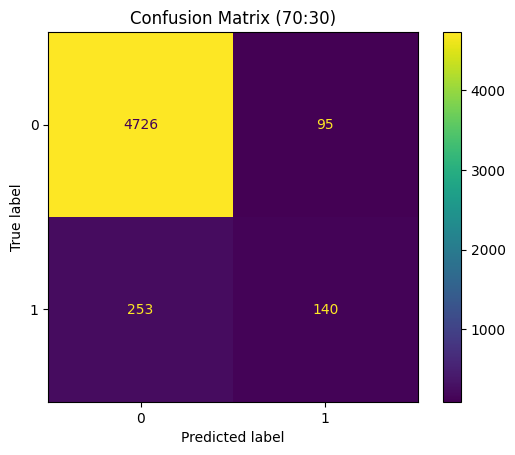

In [16]:
cm2 = confusion_matrix(y_test2, y_pred2)
print("\nConfusion Matrix (70:30):\n", cm2)

ConfusionMatrixDisplay(cm2).plot()
plt.title("Confusion Matrix (70:30)")
plt.show()

In [17]:
comparison = pd.DataFrame({
    "Split": ["80:20", "70:30"],
    "Accuracy": [acc1, acc2],
    "Precision": [prec1, prec2],
    "Recall": [rec1, rec2],
    "F1 Score": [f11, f12]
})

print("\n📊 FINAL COMPARISON TABLE")
print(comparison)


📊 FINAL COMPARISON TABLE
   Split  Accuracy  Precision    Recall  F1 Score
0  80:20  0.933544   0.923624  0.933544  0.926309
1  70:30  0.933257   0.922546  0.933257  0.925399


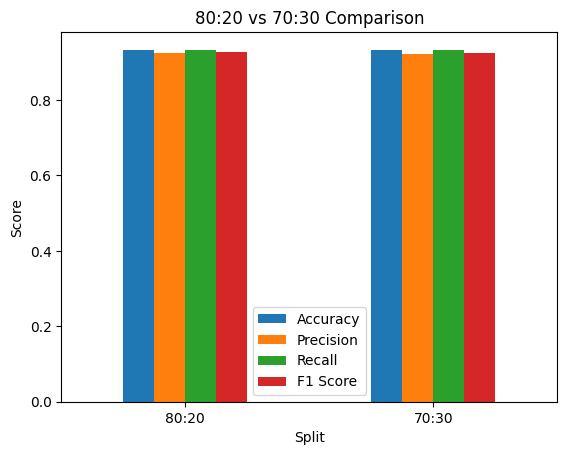

In [18]:
comparison.set_index("Split").plot(kind='bar')

plt.title("80:20 vs 70:30 Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()